# **Fabrica De Muebles - Scheduling - Visualización**


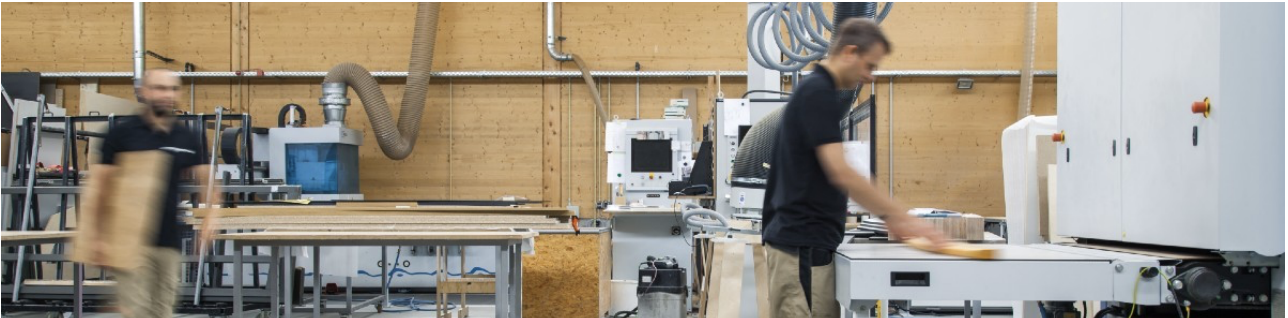

En este notebook exploraremos el punto 6 del problema de la Fabrica de Muebles. Buscaremos crear visualizaciones que nos permitan presentar la informacion de manera interactiva y facil de digerir por diversas audiencias.

In [2]:
!pip install docplex plotly streamlit ortools gradio

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 647.4/647.4 kB 14.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 81.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 66.4 MB/s eta 0:00:00
  Created wheel for docplex: filename=docplex-2.31.254-py3-none-any.whl size=686240 sha256=5f21d450db64a22a68075f8ac36b0236ecf1ab9b3dad3ecdefbfc3a13ab32378
  Stored in directory: /root/.cache/pip/wheels/9b/43/d7/d568c4f55eba9600a81c71914508b5f766ce122f560fa32cec
Successfully built docplex


## **Recordamos el problema:**

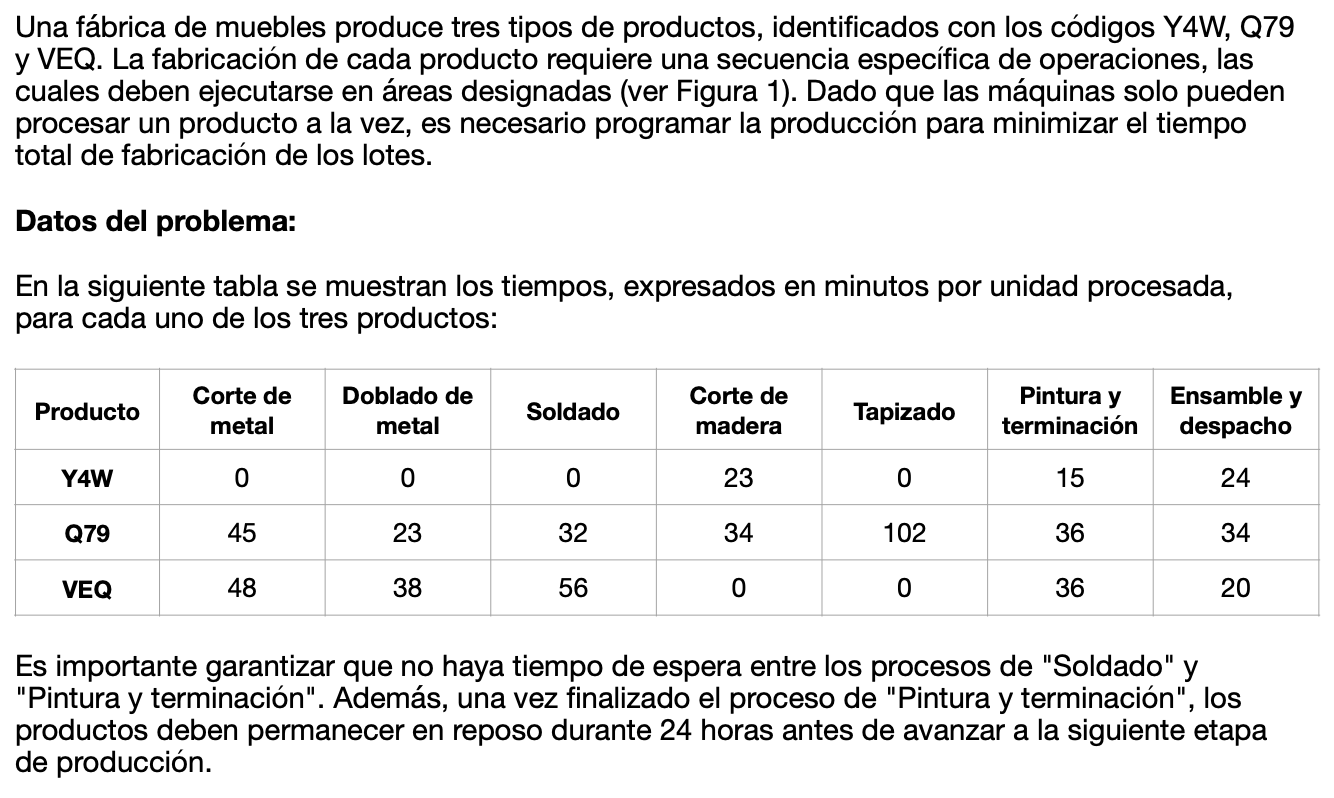

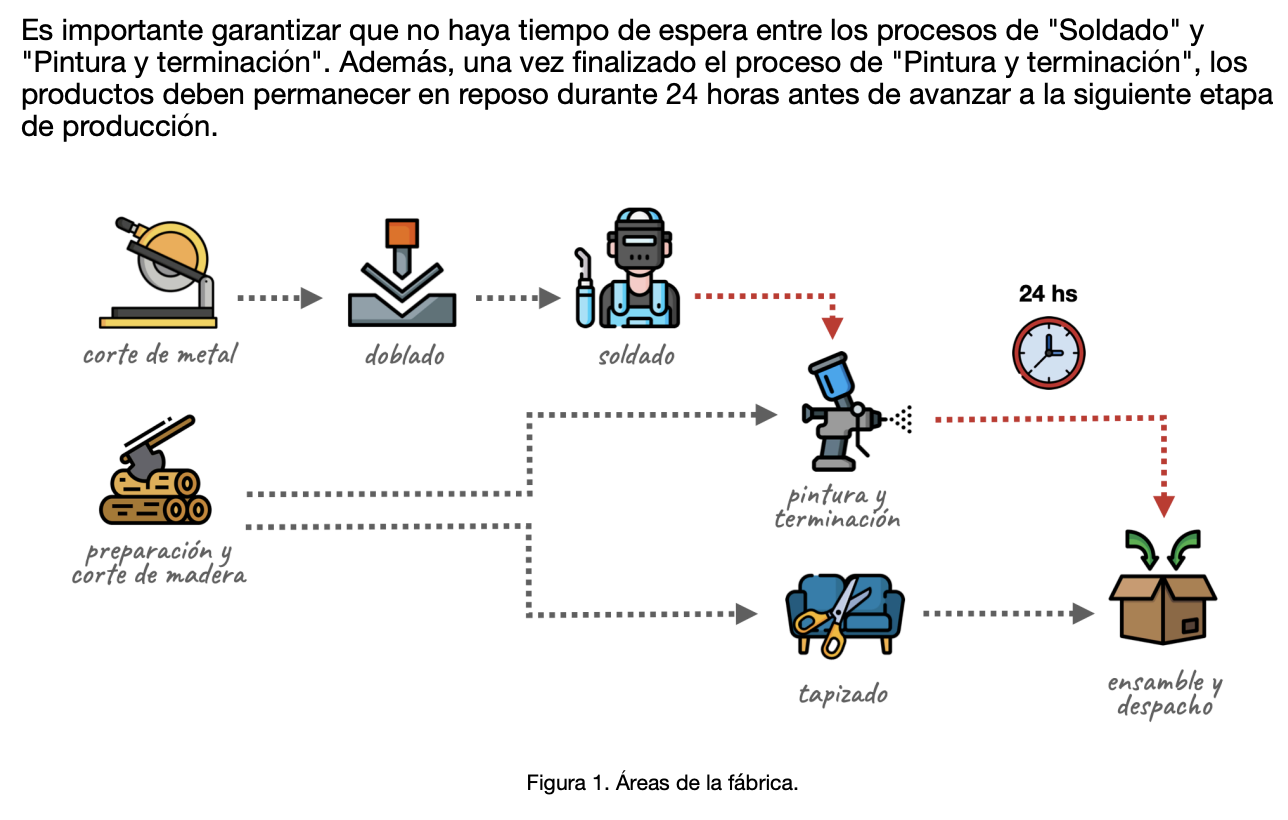

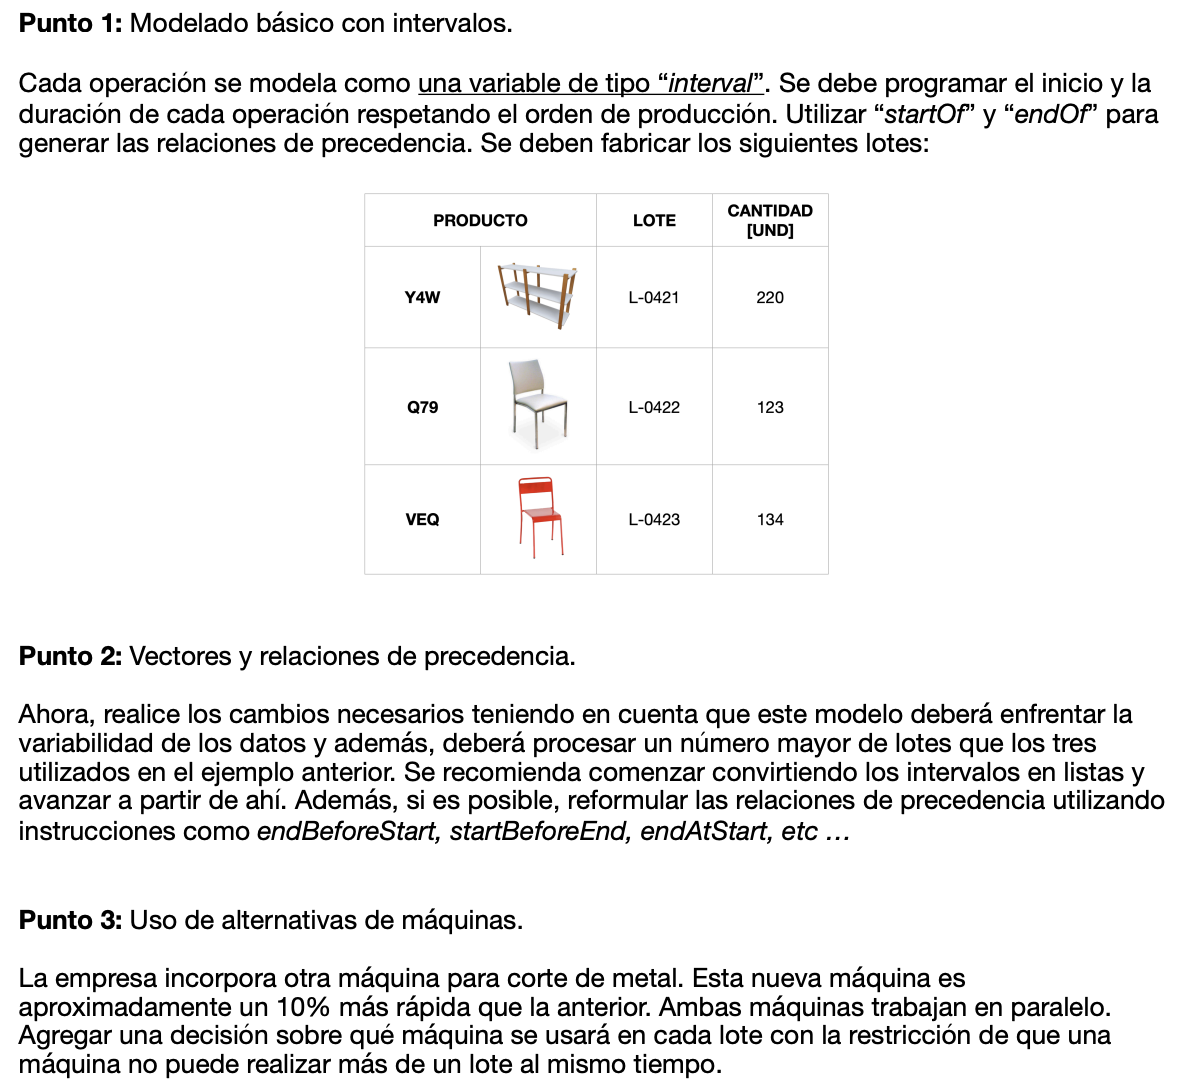

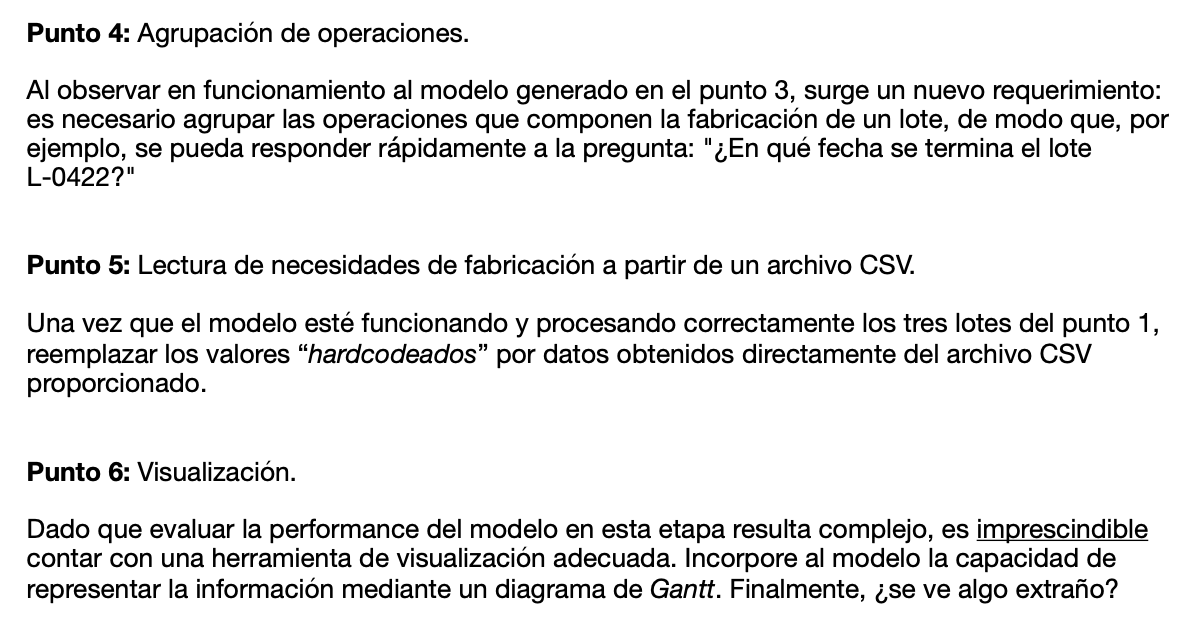

## **1 - Creamos un modelo con OR-Tools**

In [10]:
import pandas as pd
from ortools.sat.python import cp_model

# ------
# Datos
# ------
prod = {
    'Y4W': {'corte_m1': 0,'corte_m2': 0,'doblado': 0,'soldado': 0,'corte_w': 23,'tapizado': 0,'pintura': 15,'despacho': 24},
    'Q79': {'corte_m1': 45,'corte_m2': 40,'doblado': 23,'soldado': 32,'corte_w': 34,'tapizado': 102,'pintura': 36,'despacho': 34},
    'VEQ': {'corte_m1': 48,'corte_m2': 43,'doblado': 38,'soldado': 56,'corte_w': 0,'tapizado': 0,'pintura': 36,'despacho': 20}
}
op = ['corte_m1','corte_m2','doblado','soldado','corte_w','tapizado','pintura','despacho']
ultima_op = 'despacho'

REST_24H = 24 * 60


# -------------------------
# Input: nec
# Ejemplo: nec = {("L1","Q79"): 10, ("L2","VEQ"): 5, ("L3","Y4W"): 7}
# -------------------------
# nec = {...}


def solve_ortools(nec, time_limit_s=10, num_workers=8):
    model = cp_model.CpModel()
    lots = list(nec.keys())

    # Horizonte (cota grosera)
    H = 0
    for (lot_id, p) in lots:
        q = nec[(lot_id, p)]
        H += sum(prod[p][j] * q for j in op) + REST_24H
    H = max(H + 1000, 1)

    # Recursos: 1 máquina por operación, y corte metal con 2 máquinas separadas
    # (esto implementa el "un solo lote a la vez por máquina")
    RESOURCE = {
        'corte_m1': 'Corte metal M1',
        'corte_m2': 'Corte metal M2',
        'doblado': 'Doblado',
        'soldado': 'Soldado',
        'corte_w': 'Corte madera',
        'tapizado': 'Tapizado',
        'pintura': 'Pintura',
        'despacho': 'Despacho',
    }

    # Para no_overlap
    intervals_by_resource = {RESOURCE[k]: [] for k in RESOURCE}

    # Vars por (lote, op): start, end, presence, interval
    S, E, P, IV = {}, {}, {}, {}

    def add_optional_interval(lot_key, op_name, dur, force_presence=None):
        lot_id, p = lot_key
        s = model.NewIntVar(0, H, f"s_{lot_id}_{p}_{op_name}")
        e = model.NewIntVar(0, H, f"e_{lot_id}_{p}_{op_name}")
        pres = model.NewBoolVar(f"p_{lot_id}_{p}_{op_name}")
        itv = model.NewOptionalIntervalVar(s, dur, e, pres, f"itv_{lot_id}_{p}_{op_name}")

        if force_presence is not None:
            if force_presence == 1:
                model.Add(pres == 1)
            else:
                model.Add(pres == 0)

        S[(lot_key, op_name)] = s
        E[(lot_key, op_name)] = e
        P[(lot_key, op_name)] = pres
        IV[(lot_key, op_name)] = itv

        intervals_by_resource[RESOURCE[op_name]].append(itv)

    # 1) Crear intervalos
    for lot_key in lots:
        lot_id, p = lot_key
        q = nec[lot_key]

        # duraciones por operación para este lote
        dur = {j: int(prod[p][j] * q) for j in op}

        # Creamos todo como optional; luego forzamos presencias
        for j in op:
            add_optional_interval(lot_key, j, dur[j])

        # Presencias por producto
        if p == 'Y4W':
            for j in ['corte_m1','corte_m2','doblado','soldado','tapizado']:
                model.Add(P[(lot_key, j)] == 0)
            for j in ['corte_w','pintura','despacho']:
                model.Add(P[(lot_key, j)] == 1)

        if p == 'Q79':
            # Exactly one de corte metal
            model.Add(P[(lot_key,'corte_m1')] + P[(lot_key,'corte_m2')] == 1)
            for j in ['doblado','soldado','corte_w','tapizado','pintura','despacho']:
                model.Add(P[(lot_key, j)] == 1)

        if p == 'VEQ':
            model.Add(P[(lot_key,'corte_m1')] + P[(lot_key,'corte_m2')] == 1)
            for j in ['doblado','soldado','pintura','despacho']:
                model.Add(P[(lot_key, j)] == 1)
            for j in ['corte_w','tapizado']:
                model.Add(P[(lot_key, j)] == 0)

    # 2) NoOverlap por recurso
    for r, itvs in intervals_by_resource.items():
        if itvs:
            model.AddNoOverlap(itvs)

    # Helper: precedencia condicional (solo si ambos presentes)
    def add_end_before_start(lot_key, a, b, lag=0):
        # e_a + lag <= s_b si a y b presentes
        model.Add(E[(lot_key, a)] + lag <= S[(lot_key, b)]).OnlyEnforceIf([P[(lot_key, a)], P[(lot_key, b)]])

    def add_end_at_start(lot_key, a, b):
        model.Add(E[(lot_key, a)] == S[(lot_key, b)]).OnlyEnforceIf([P[(lot_key, a)], P[(lot_key, b)]])

    # 3) Precedencias
    for lot_key in lots:
        lot_id, p = lot_key

        if p == 'Y4W':
            add_end_before_start(lot_key, 'corte_w', 'pintura')
            add_end_before_start(lot_key, 'pintura', 'despacho', REST_24H)

        if p == 'Q79':
            # corte_m1/corte_m2 -> doblado (condicional por presencia del corte elegido)
            add_end_before_start(lot_key, 'corte_m1', 'doblado')
            add_end_before_start(lot_key, 'corte_m2', 'doblado')

            add_end_before_start(lot_key, 'doblado', 'soldado')
            add_end_at_start(lot_key, 'soldado', 'pintura')     # no-wait
            add_end_before_start(lot_key, 'pintura', 'despacho', REST_24H)

            add_end_before_start(lot_key, 'corte_w', 'tapizado')
            add_end_before_start(lot_key, 'tapizado', 'despacho')

        if p == 'VEQ':
            add_end_before_start(lot_key, 'corte_m1', 'doblado')
            add_end_before_start(lot_key, 'corte_m2', 'doblado')

            add_end_before_start(lot_key, 'doblado', 'soldado')
            add_end_at_start(lot_key, 'soldado', 'pintura')     # no-wait
            add_end_before_start(lot_key, 'pintura', 'despacho', REST_24H)

    # 4) Objetivo: minimizar makespan = max end(despacho)
    makespan = model.NewIntVar(0, H, "makespan")
    ends = [E[(lot_key, ultima_op)] for lot_key in lots]
    model.AddMaxEquality(makespan, ends)
    model.Minimize(makespan)

    # Solve
    solver = cp_model.CpSolver()
    solver.parameters.max_time_in_seconds = float(time_limit_s)
    solver.parameters.num_search_workers = int(num_workers)

    status = solver.Solve(model)

    info = {
        "status": solver.StatusName(status),
        "makespan": solver.Value(makespan) if status in (cp_model.OPTIMAL, cp_model.FEASIBLE) else None,
    }

    if status not in (cp_model.OPTIMAL, cp_model.FEASIBLE):
        return pd.DataFrame(), info

    # 5) Export schedule_df (para Gantt)
    rows = []
    for lot_key in lots:
        lot_id, p = lot_key
        q = nec[lot_key]
        for j in op:
            if solver.Value(P[(lot_key, j)]) == 0:
                continue
            rows.append({
                "lot_id": lot_id,
                "product": p,
                "quantity": int(q),
                "op_code": j,
                "resource": RESOURCE[j],
                "start_min": int(solver.Value(S[(lot_key, j)])),
                "end_min": int(solver.Value(E[(lot_key, j)])),
            })

    schedule_df = pd.DataFrame(rows).sort_values(["resource","start_min","lot_id"]).reset_index(drop=True)
    schedule_df["duration_min"] = schedule_df["end_min"] - schedule_df["start_min"]

    return schedule_df, info

## **2 - Punto 6: Creamos visualizaciones con Plotly**

> Primero leemos los datos del CSV y lo convertimos en un diccionario de necesidades

In [35]:
# DATOS

import pandas as pd

df = pd.read_csv('P_C04-1C2025_data.csv', sep = ';')

nec = {}

for _, fila in df.iterrows():
    nec.update({(fila.LOT, fila.PRODUCT): fila.QTY} )


In [36]:
df

,LOT,PRODUCT,QTY
0,L-0505,Q79,55
1,L-0506,Q79,60
2,L-0507,Y4W,134
3,L-0508,Q79,136
4,L-0509,Y4W,112
5,L-0510,Q79,149
6,L-0511,Q79,89
7,L-0512,Q79,103
8,L-0513,VEQ,65
9,L-0514,Y4W,89


> Enviamos los requerimientos al modelo y resolvemos

In [14]:
schedule_df, info = solve_ortools(nec, time_limit_s=10)
info

{'status': 'OPTIMAL', 'makespan': 78268}

In [21]:
78268/60/60

21.741111111111113

In [16]:
schedule_df.head()

,lot_id,product,quantity,op_code,resource,start_min,end_min,duration_min
0,L-0506,Q79,60,corte_w,Corte madera,0,2040,2040
1,L-0514,Y4W,89,corte_w,Corte madera,2040,4087,2047
2,L-0511,Q79,89,corte_w,Corte madera,4087,7113,3026
3,L-0509,Y4W,112,corte_w,Corte madera,7113,9689,2576
4,L-0512,Q79,103,corte_w,Corte madera,9689,13191,3502


> Visualizamos!

In [22]:
import plotly.graph_objects as go

df = schedule_df.copy()

MIN_PER_DAY = 1440
VIEW_IN_DAYS = True

scale = MIN_PER_DAY if VIEW_IN_DAYS else 1
unit = "days" if VIEW_IN_DAYS else "min"

df["start"] = df["start_min"] / scale
df["duration"] = (df["end_min"] - df["start_min"]) / scale

fig = go.Figure()

for lot in df["lot_id"].unique():
    d = df[df["lot_id"] == lot]

    # texto dentro de cada caja
    labels = [
        f"{p}<br>{l}"   # producto + lote
        for p, l in zip(d["product"], d["lot_id"])
    ]

    fig.add_bar(
        y=d["resource"],
        x=d["duration"],
        base=d["start"],
        orientation="h",
        name=lot,

        text=labels,              # texto visible del producto - lote
        textposition="inside",    # dentro de la barra
        textfont=dict(size=11),

        hovertemplate=(
            "<b>%{customdata[0]}</b><br>"
            "Producto: %{customdata[1]}<br>"
            "Inicio: %{base:.2f}<br>"
            "Duración: %{x:.2f}<extra></extra>"
        ),
        customdata=d[["lot_id","product"]].values,
    )

fig.update_layout(
    title="Gantt Scheduling",
    barmode="overlay",
    height=700,
    xaxis_title=f"Tiempo ({unit})",
    yaxis_title="Recurso",
)

fig.update_yaxes(autorange="reversed")

fig.show()

#### Grafico de torta: Product Mix

In [54]:
import plotly.express as px

def plot_product_mix(df_dem):
    # df_dem tiene LOT, PRODUCT, QTY
    agg = df_dem.groupby("PRODUCT", as_index=False)["QTY"].sum()
    fig = px.pie(agg, names="PRODUCT", values="QTY", hole=0.45, title="Mix de productos (QTY)")
    fig.update_traces(textinfo="percent+label")
    return fig

plot_product_mix(df)

### Barplot: Utilizacion por recurso

In [58]:
def plot_utilization_bar(schedule_df):
    makespan = schedule_df["end_min"].max()
    util = schedule_df.groupby("resource", as_index=False)["duration_min"].sum()
    util["utilization"] = util["duration_min"] / makespan
    util = util.sort_values("utilization", ascending=False)
    fig = px.bar(util, x="resource", y="utilization", title="Utilización por recurso")
    fig.update_layout(yaxis_tickformat=".0%")  # 0-1 → %
    return fig

plot_utilization_bar(schedule_df)

### Line plot: “WIP” (trabajo en proceso) en funcion del tiempo

In [59]:
import numpy as np

def plot_wip_line(schedule_df, bin_minutes=240):
    ms = schedule_df["end_min"].max()
    bins = np.arange(0, ms + bin_minutes, bin_minutes)

    # WIP(t) = tareas activas (cualquier recurso) en cada bin
    wip = []
    for i in range(len(bins)-1):
        t0, t1 = bins[i], bins[i+1]
        active = ((schedule_df["start_min"] < t1) & (schedule_df["end_min"] > t0)).sum()
        wip.append(active)

    dfw = pd.DataFrame({
        "time_days": bins[:-1] / 1440,
        "wip": wip
    })

    fig = px.line(dfw, x="time_days", y="wip", title="WIP (tareas activas) en el tiempo")
    fig.update_layout(xaxis_title="Tiempo (días)", yaxis_title="WIP")
    return fig

plot_wip_line(schedule_df)

### Scatter: correlaciones. Tiempo vs Tamaño de lote

In [60]:
def plot_lot_size_vs_total_time(schedule_df):
    lot_total = schedule_df.groupby(["lot_id","product","quantity"], as_index=False)["duration_min"].sum()
    lot_total["total_days"] = lot_total["duration_min"] / 1440
    fig = px.scatter(
        lot_total,
        x="quantity",
        y="total_days",
        color="product",
        hover_data=["lot_id"],
        title="Tamaño de lote vs tiempo total de proceso (suma de duraciones)"
    )
    fig.update_layout(xaxis_title="QTY", yaxis_title="Total (días)")
    return fig

plot_lot_size_vs_total_time(schedule_df)

### Boxplot: Distribuciones de tiempos por Operacion

In [61]:
def plot_duration_box(schedule_df):
    df = schedule_df.copy()
    df["dur_days"] = df["duration_min"]/1440
    fig = px.box(df, x="op_code", y="dur_days", points="all", title="Distribución de duración por operación")
    fig.update_layout(xaxis_title="Operación", yaxis_title="Duración (días)")
    return fig

plot_duration_box(schedule_df)

### Lote mas grande

In [64]:
def plot_lot_sizes(df_dem):
    df = df_dem.copy()

    agg = (
        df.groupby(["LOT", "PRODUCT"], as_index=False)["QTY"]
        .sum()
        .sort_values("QTY", ascending=False)
    )

    fig = px.bar(
        agg,
        x="LOT",
        y="QTY",
        color="PRODUCT",
        title="Cantidad de unidades por lote",
        text="QTY",
    )

    # highlight lote más grande
    max_row = agg.iloc[0]

    fig.add_annotation(
        x=max_row["LOT"],
        y=max_row["QTY"],
        text="⬆ Lote más grande",
        showarrow=True,
        arrowhead=2,
        yshift=15
    )

    fig.update_traces(textposition="outside")

    fig.update_layout(
        height=420,
        xaxis_title="Lote",
        yaxis_title="Unidades",
        margin=dict(r=30, l=30, t=60, b=30),
    )

    return fig

plot_lot_sizes(df)

## **3 - WebApp Interactiva con Plotly + Gradio**

In [67]:
import gradio as gr
import pandas as pd
import numpy as np
import plotly.graph_objects as go
import plotly.express as px

MIN_PER_DAY = 1440

# -----------------------------
# Plotly builders
# -----------------------------
def build_gantt(schedule_df, view_in_days=True):
    df = schedule_df.copy()
    scale = MIN_PER_DAY if view_in_days else 1
    unit = "days" if view_in_days else "min"

    df["start"] = df["start_min"] / scale
    df["duration"] = (df["end_min"] - df["start_min"]) / scale

    fig = go.Figure()
    for lot in df["lot_id"].unique():
        d = df[df["lot_id"] == lot]
        labels = [f"{p}<br>{l}" for p, l in zip(d["product"], d["lot_id"])]
        fig.add_bar(
            y=d["resource"], x=d["duration"], base=d["start"],
            orientation="h", name=lot,
            text=labels, textposition="inside",
        )

    makespan = df["end_min"].max() / scale
    fig.add_vline(x=makespan, line_width=2, line_dash="dash")
    fig.add_annotation(
        x=makespan, y=1.02, xref="x", yref="paper",
        text=f"Makespan = {makespan:.2f} {unit}",
        showarrow=False
    )

    fig.update_layout(
        height=620,
        title="Production Schedule (Gantt)",
        xaxis_title=f"Tiempo ({unit})",
        yaxis_title="Recurso",
        barmode="overlay",
        legend=dict(x=1.02, y=1, xanchor="left", yanchor="top"),
        margin=dict(r=230),
    )
    fig.update_yaxes(autorange="reversed")
    return fig


def plot_product_mix(df_dem):
    agg = df_dem.groupby("PRODUCT", as_index=False)["QTY"].sum()
    fig = px.pie(agg, names="PRODUCT", values="QTY", hole=0.45, title="Mix de productos (QTY)")
    fig.update_traces(textinfo="percent+label")
    fig.update_layout(height=380, margin=dict(r=30, l=30, t=60, b=30))
    return fig


def plot_utilization_bar(schedule_df):
    ms = schedule_df["end_min"].max()
    util = schedule_df.groupby("resource", as_index=False)["duration_min"].sum()
    util["utilization"] = util["duration_min"] / ms
    util = util.sort_values("utilization", ascending=False)

    fig = px.bar(util, x="resource", y="utilization", title="Utilización por recurso")
    fig.update_layout(height=380, xaxis_title="", yaxis_title="Utilización", margin=dict(r=30, l=30, t=60, b=30))
    fig.update_yaxes(tickformat=".0%")
    return fig


def plot_wip_line(schedule_df, bin_minutes=240):
    ms = schedule_df["end_min"].max()
    bins = np.arange(0, ms + bin_minutes, bin_minutes)

    wip = []
    for i in range(len(bins) - 1):
        t0, t1 = bins[i], bins[i + 1]
        active = ((schedule_df["start_min"] < t1) & (schedule_df["end_min"] > t0)).sum()
        wip.append(int(active))

    dfw = pd.DataFrame({"time_days": bins[:-1] / 1440, "wip": wip})
    fig = px.line(dfw, x="time_days", y="wip", title="WIP (tareas activas) en el tiempo")
    fig.update_layout(height=380, xaxis_title="Tiempo (días)", yaxis_title="WIP", margin=dict(r=30, l=30, t=60, b=30))
    return fig


def plot_lot_scatter(schedule_df):
    lot_total = schedule_df.groupby(["lot_id","product","quantity"], as_index=False)["duration_min"].sum()
    lot_total["total_days"] = lot_total["duration_min"] / 1440
    fig = px.scatter(
        lot_total, x="quantity", y="total_days", color="product",
        hover_data=["lot_id"], title="Tamaño de lote vs tiempo total (suma duraciones)"
    )
    fig.update_layout(height=380, xaxis_title="QTY", yaxis_title="Total (días)", margin=dict(r=30, l=30, t=60, b=30))
    return fig


def plot_duration_box(schedule_df):
    df = schedule_df.copy()
    df["dur_days"] = df["duration_min"] / 1440
    fig = px.box(df, x="op_code", y="dur_days", points="all", title="Distribución de duración por operación")
    fig.update_layout(height=380, xaxis_title="Operación", yaxis_title="Duración (días)", margin=dict(r=30, l=30, t=60, b=30))
    return fig


# -----------------------------
# IO + pipeline
# -----------------------------
def read_demand_csv(file_obj):
    # autodetect , vs ; (y fallback)
    try:
        df = pd.read_csv(file_obj.name, sep=None, engine="python")
    except Exception:
        df = pd.read_csv(file_obj.name, sep=";")

    # normalize cols
    df.columns = (df.columns.astype(str)
                  .str.replace("\ufeff", "", regex=False)
                  .str.strip()
                  .str.upper())
    return df

def run_all(file_obj):
    df_dem = read_demand_csv(file_obj)

    required = {"LOT", "PRODUCT", "QTY"}
    if not required.issubset(set(df_dem.columns)):
        msg = f"CSV inválido. Esperadas: {sorted(required)}. Detectadas: {list(df_dem.columns)}"
        return None, None, None, None, None, None, msg

    # nec for solver
    nec = {(r["LOT"], r["PRODUCT"]): int(r["QTY"]) for _, r in df_dem.iterrows()}

    # solve (asume solve_ortools ya definido arriba en notebook)
    schedule_df, info = solve_ortools(nec)

    if schedule_df is None or len(schedule_df) == 0:
        return None, None, None, None, None, None, f"No hay solución. Info: {info}"

    if "duration_min" not in schedule_df.columns:
        schedule_df = schedule_df.copy()
        schedule_df["duration_min"] = schedule_df["end_min"] - schedule_df["start_min"]

    ms = info.get("makespan", schedule_df["end_min"].max())

    gantt = build_gantt(schedule_df, view_in_days=True)
    mix = plot_product_mix(df_dem)
    util = plot_utilization_bar(schedule_df)
    wip = plot_wip_line(schedule_df)
    sca = plot_lot_scatter(schedule_df)
    box = plot_duration_box(schedule_df)
    lot_sizes = plot_lot_sizes(df_dem)

    summary = f"Status: {info.get('status')} | Makespan: {ms/1440:.2f} días ({ms} min) | Lotes: {schedule_df['lot_id'].nunique()} | Ops: {len(schedule_df)}"
    return gantt, mix, util, wip, sca, box, lot_sizes, summary


# -----------------------------
# Gradio UI (2 tabs)
# -----------------------------
css_fix = """
/* evita que la modebar de plotly tape la leyenda o capture clicks */
.js-plotly-plot .plotly .modebar { z-index: 1 !important; }
.js-plotly-plot .plotly .legend { z-index: 10 !important; }
/* un poco de padding general */
.gradio-container { max-width: 1200px !important; }
"""

with gr.Blocks(css=css_fix) as demo:
    gr.Markdown("# 🪑 Scheduling Optimizer")
    gr.Markdown("Subí CSV con columnas: **LOT, PRODUCT, QTY** (detecta `,` o `;`).")

    uploader = gr.UploadButton("📤 Subir CSV", file_types=[".csv"], file_count="single")
    summary = gr.Textbox(label="Resultado", lines=2)

    with gr.Tabs():
        with gr.Tab("Gantt"):
            gantt_plot = gr.Plot()
        with gr.Tab("Analytics"):
            with gr.Row():
                mix_plot = gr.Plot()
                util_plot = gr.Plot()
            with gr.Row():
                wip_plot = gr.Plot()
                scatter_plot = gr.Plot()
            with gr.Row():
              box_plot = gr.Plot()
              lot_sizes_plot = gr.Plot()

    uploader.upload(
        fn=run_all,
        inputs=[uploader],
        outputs=[
            gantt_plot,
            mix_plot,
            util_plot,
            wip_plot,
            scatter_plot,
            box_plot,
            lot_sizes_plot,
            summary
        ],
        queue=False
    )

demo.launch(share=False)

/tmp/ipython-input-429/1430483222.py:169: DeprecationWarning:

The 'css' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'css' to Blocks.launch() instead.



Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
Note: opening Chrome Inspector may crash demo inside Colab notebooks.
* To create a public link, set `share=True` in `launch()`.


<IPython.core.display.Javascript object>

## **4 - Próximos Pasos**

Hasta ahora construimos un dashboard interactivo combinando:

-   🧠 Optimización
-   📊 Visualización con Plotly
-   🌐 Interfaces con Gradio

> Ahora la idea es que empiecen a explorar por su cuenta y aprendan a
crear visualizaciones propias.
------------------------------------------------------------------------

📚 1. Explorar Plotly

Docs oficiales: https://plotly.com/python/

Dos formas principales:

✅ Plotly Express (rápido y simple)

px.bar(…) px.line(…) px.scatter(…) px.pie(…) px.box(…)

Ideal para explorar datos rápidamente.

✅ Graph Objects (más control)

go.Figure() fig.add_trace(…) fig.update_layout(…)

Sirve para customizar layouts y dashboards más avanzados.

------------------------------------------------------------------------

Challenges Opcionales (Plotly)

Agreguen al menos 2 plots nuevos al dashboard:

-   Histogram de duraciones
-   Line plot acumulado
-   Scatter entre variables interesantes
-   Ranking de recursos o productos

Intenten responder visualmente preguntas como:

-   ¿Cuál es el cuello de botella?
-   ¿Qué producto domina la producción?
-   ¿Qué lote tarda más?

------------------------------------------------------------------------

2. Explorar Gradio

Docs: https://www.gradio.app/docs

Idea central:

inputs → función → outputs

Prueben agregar:

-   Dropdown para elegir producto
-   Slider de granularidad temporal
-   Checkbox para filtrar información
-   Nuevos outputs (DataFrame, Markdown, KPIs)

------------------------------------------------------------------------

Challenges Opcionales: hacer el dashboard más lindo

Intenten mejorar el diseño:

-   Cambiar colores y themes
-   Agregar títulos claros
-   Usar anotaciones (add_annotation)
-   Destacar insights importantes
-   Ordenar plots en filas/columnas más limpias
-   Reducir ruido visual

Pregúntense siempre: ¿Este gráfico ayuda a entender algo más rápido?

### Out del notebook, como ejemplo para motivarlos:

In [80]:
import gradio as gr
import pandas as pd
import numpy as np
import plotly.graph_objects as go
import plotly.express as px

MIN_PER_DAY = 1440

# ─────────────────────────────────────────────
# Curated colors (replace default Plotly rainbow)
# ─────────────────────────────────────────────
LOT_COLORS = [
    "#4A6FA5", "#D4622B", "#2B7A5F", "#C2534C", "#7B6BA4",
    "#D4953A", "#3A8A8A", "#8B6E4E", "#6B8E5A", "#B85C8A",
    "#5B7E9E", "#C47A3A", "#6A7E6A", "#9E6B6B", "#4A8E7A",
    "#A0764A", "#6B6BA0", "#8E7B5A", "#5A8E8E", "#A06B8E",
]

PRODUCT_COLORS = {"Q79": "#4A6FA5", "Y4W": "#D4622B", "VEQ": "#2B7A5F"}

# Font string reused across all charts
FONT = "DM Sans, Helvetica Neue, sans-serif"


# -----------------------------
# Plotly builders
# -----------------------------
def build_gantt(schedule_df, view_in_days=True):
    df = schedule_df.copy()
    scale = MIN_PER_DAY if view_in_days else 1
    unit = "days" if view_in_days else "min"

    df["start"] = df["start_min"] / scale
    df["duration"] = (df["end_min"] - df["start_min"]) / scale

    lots = df["lot_id"].unique().tolist()
    cmap = {lot: LOT_COLORS[i % len(LOT_COLORS)] for i, lot in enumerate(lots)}

    fig = go.Figure()
    for lot in lots:
        d = df[df["lot_id"] == lot]
        labels = [f"<b>{p}</b><br><span style='font-size:9px'>{l}</span>"
                  for p, l in zip(d["product"], d["lot_id"])]
        fig.add_bar(
            y=d["resource"], x=d["duration"], base=d["start"],
            orientation="h", name=lot,
            text=labels, textposition="inside",
            insidetextfont=dict(size=10, color="white", family=FONT),
            marker=dict(
                color=cmap[lot],
                line=dict(width=0.5, color="rgba(255,255,255,0.6)"),
            ),
        )

    makespan = df["end_min"].max() / scale
    fig.add_vline(x=makespan, line_width=1.5, line_dash="dot",
                  line_color="#D4622B")
    fig.add_annotation(
        x=makespan, y=1.02, xref="x", yref="paper",
        text=f"<b>Makespan {makespan:.1f} {unit}</b>",
        showarrow=False,
        font=dict(size=12, color="#D4622B", family=FONT),
    )

    n_resources = df["resource"].nunique()
    n_lots = len(lots)
    chart_height = max(520, n_resources * 80 + 200)
    legend_rows = max(1, (n_lots + 5) // 6)
    bottom_margin = 60 + legend_rows * 22

    fig.update_layout(
        height=chart_height,
        title=dict(text="Plan de producción (Gantt)", font=dict(size=17, family=FONT)),
        xaxis_title=f"Tiempo ({unit})",
        yaxis_title=None,
        barmode="overlay",
        font=dict(family=FONT, size=12),
        plot_bgcolor="#FAFAFA",
        paper_bgcolor="white",
        legend=dict(
            orientation="h", yanchor="top", y=-0.08,
            xanchor="center", x=0.5,
            font=dict(size=10), bgcolor="rgba(0,0,0,0)",
        ),
        margin=dict(t=48, r=16, b=bottom_margin, l=130),
        xaxis=dict(gridcolor="#EEEEEE", zerolinecolor="#EEEEEE"),
        yaxis=dict(gridcolor="#EEEEEE"),
    )
    fig.update_yaxes(autorange="reversed", tickfont=dict(size=12))
    return fig


def plot_product_mix(df_dem):
    agg = df_dem.groupby("PRODUCT", as_index=False)["QTY"].sum()
    colors = [PRODUCT_COLORS.get(p, "#999") for p in agg["PRODUCT"]]

    fig = px.pie(agg, names="PRODUCT", values="QTY", hole=0.5,
                 color_discrete_sequence=colors)
    fig.update_traces(
        textinfo="percent+label",
        textfont=dict(size=13, color="white", family=FONT),
        marker=dict(colors=colors, line=dict(color="white", width=2)),
    )
    fig.update_layout(
        height=400, title=dict(text="🧁 Mix de productos", font=dict(size=15, family=FONT)),
        paper_bgcolor="white", plot_bgcolor="white",
        font=dict(family=FONT),
        margin=dict(r=30, l=30, t=60, b=30),
    )
    return fig


def plot_utilization_bar(schedule_df):
    ms = schedule_df["end_min"].max()
    util = schedule_df.groupby("resource", as_index=False)["duration_min"].sum()
    util["utilization"] = util["duration_min"] / ms
    util = util.sort_values("utilization", ascending=False)

    fig = go.Figure(go.Bar(
        x=util["resource"], y=util["utilization"],
        marker=dict(
            color=util["utilization"],
            colorscale=[[0, "#C8DCC0"], [0.5, "#5A9E6F"], [1, "#2B7A5F"]],
            cornerradius=4,
        ),
        text=[f"{v:.0%}" for v in util["utilization"]],
        textposition="outside",
        textfont=dict(size=11, color="#888", family=FONT),
    ))
    fig.update_layout(
        height=400,
        title=dict(text="🔧 Utilización por recurso", font=dict(size=15, family=FONT)),
        xaxis_title="", yaxis_title="Utilización",
        font=dict(family=FONT), paper_bgcolor="white", plot_bgcolor="#FAFAFA",
        margin=dict(r=30, l=50, t=60, b=80),
        yaxis=dict(tickformat=".0%", gridcolor="#EEEEEE"),
        xaxis=dict(gridcolor="#EEEEEE"),
    )
    fig.update_xaxes(tickangle=-30)
    return fig


def plot_wip_line(schedule_df, bin_minutes=240):
    ms = schedule_df["end_min"].max()
    bins = np.arange(0, ms + bin_minutes, bin_minutes)

    wip = []
    for i in range(len(bins) - 1):
        t0, t1 = bins[i], bins[i + 1]
        active = ((schedule_df["start_min"] < t1) & (schedule_df["end_min"] > t0)).sum()
        wip.append(int(active))

    dfw = pd.DataFrame({"time_days": bins[:-1] / 1440, "wip": wip})

    fig = go.Figure()
    fig.add_scatter(
        x=dfw["time_days"], y=dfw["wip"], mode="lines",
        line=dict(color="#4A6FA5", width=2),
        fill="tozeroy", fillcolor="rgba(74, 111, 165, 0.08)",
    )
    fig.update_layout(
        height=400,
        title=dict(text="📈 WIP en el taller", font=dict(size=15, family=FONT)),
        xaxis_title="Tiempo (días)", yaxis_title="Tareas activas",
        font=dict(family=FONT), paper_bgcolor="white", plot_bgcolor="#FAFAFA",
        margin=dict(r=30, l=50, t=60, b=50),
        xaxis=dict(gridcolor="#EEEEEE"), yaxis=dict(gridcolor="#EEEEEE"),
    )
    return fig


def plot_lot_scatter(schedule_df):
    lot_total = schedule_df.groupby(
        ["lot_id", "product", "quantity"], as_index=False
    )["duration_min"].sum()
    lot_total["total_days"] = lot_total["duration_min"] / 1440

    fig = go.Figure()
    for prod, color in PRODUCT_COLORS.items():
        mask = lot_total["product"] == prod
        if mask.any():
            sub = lot_total[mask]
            fig.add_scatter(
                x=sub["quantity"], y=sub["total_days"],
                mode="markers", name=prod,
                marker=dict(size=10, color=color, opacity=0.85,
                            line=dict(width=1, color="white")),
                hovertext=sub["lot_id"],
            )
    fig.update_layout(
        height=400,
        title=dict(text="🚀 Lote vs tiempo total", font=dict(size=15, family=FONT)),
        xaxis_title="Cantidad", yaxis_title="Total (días)",
        font=dict(family=FONT), paper_bgcolor="white", plot_bgcolor="#FAFAFA",
        margin=dict(r=30, l=50, t=60, b=50),
        xaxis=dict(gridcolor="#EEEEEE"), yaxis=dict(gridcolor="#EEEEEE"),
    )
    return fig


def plot_duration_box(schedule_df):
    df = schedule_df.copy()
    df["dur_days"] = df["duration_min"] / 1440

    fig = px.box(df, x="op_code", y="dur_days", points="all",
                 color_discrete_sequence=["#4A6FA5"])
    fig.update_traces(
        marker=dict(size=4, opacity=0.5, color="#4A6FA5"),
        line=dict(color="#4A6FA5"),
        fillcolor="rgba(74, 111, 165, 0.10)",
    )
    fig.update_layout(
        height=400,
        title=dict(text="🧪 Distribución de duraciones", font=dict(size=15, family=FONT)),
        xaxis_title="Operación", yaxis_title="Duración (días)",
        font=dict(family=FONT), paper_bgcolor="white", plot_bgcolor="#FAFAFA",
        margin=dict(r=30, l=50, t=60, b=80),
        xaxis=dict(gridcolor="#EEEEEE"), yaxis=dict(gridcolor="#EEEEEE"),
    )
    fig.update_xaxes(tickangle=-30)
    return fig


def plot_lot_sizes(df_dem):
    agg = df_dem.sort_values("QTY", ascending=False)
    colors = [PRODUCT_COLORS.get(p, "#999") for p in agg["PRODUCT"]]

    fig = go.Figure(go.Bar(
        x=agg["LOT"], y=agg["QTY"],
        marker=dict(color=colors, cornerradius=3),
        text=agg["QTY"], textposition="outside",
        textfont=dict(size=10, color="#888", family=FONT),
    ))

    max_idx = agg["QTY"].idxmax()
    mr = agg.loc[max_idx]
    fig.add_annotation(
        x=mr["LOT"], y=mr["QTY"], text="⬆ Mayor",
        showarrow=True, arrowhead=0, arrowcolor="#aaa",
        font=dict(size=10, color="#999"), yshift=18,
    )

    fig.update_layout(
        height=400,
        title=dict(text="📦 Unidades por lote", font=dict(size=15, family=FONT)),
        xaxis_title="Lote", yaxis_title="Unidades",
        font=dict(family=FONT), paper_bgcolor="white", plot_bgcolor="#FAFAFA",
        margin=dict(r=30, l=50, t=60, b=80),
        xaxis=dict(gridcolor="#EEEEEE"), yaxis=dict(gridcolor="#EEEEEE"),
    )
    fig.update_xaxes(tickangle=-45)
    return fig


# -----------------------------
# IO + pipeline
# -----------------------------
def read_demand_csv(file_obj):
    try:
        df = pd.read_csv(file_obj.name, sep=None, engine="python")
    except Exception:
        df = pd.read_csv(file_obj.name, sep=";")

    df.columns = (df.columns.astype(str)
                  .str.replace("\ufeff", "", regex=False)
                  .str.strip()
                  .str.upper())
    return df

def run_all(file_obj):
    df_dem = read_demand_csv(file_obj)

    required = {"LOT", "PRODUCT", "QTY"}
    if not required.issubset(set(df_dem.columns)):
        msg = f"CSV inválido. Esperadas: {sorted(required)}. Detectadas: {list(df_dem.columns)}"
        return None, None, None, None, None, None, None, msg

    nec = {(r["LOT"], r["PRODUCT"]): int(r["QTY"]) for _, r in df_dem.iterrows()}

    schedule_df, info = solve_ortools(nec)

    if schedule_df is None or len(schedule_df) == 0:
        return None, None, None, None, None, None, None, f"No hay solución. Info: {info}"

    if "duration_min" not in schedule_df.columns:
        schedule_df = schedule_df.copy()
        schedule_df["duration_min"] = schedule_df["end_min"] - schedule_df["start_min"]

    ms = info.get("makespan", schedule_df["end_min"].max())

    gantt = build_gantt(schedule_df, view_in_days=True)
    mix = plot_product_mix(df_dem)
    util = plot_utilization_bar(schedule_df)
    wip = plot_wip_line(schedule_df)
    sca = plot_lot_scatter(schedule_df)
    box = plot_duration_box(schedule_df)
    lot_sizes = plot_lot_sizes(df_dem)

    summary = (f"✅ {info.get('status')}  ·  "
               f"Makespan: {ms/1440:.1f} días ({ms:,} min)  ·  "
               f"{schedule_df['lot_id'].nunique()} lotes  ·  "
               f"{len(schedule_df)} ops")
    return gantt, mix, util, wip, sca, box, lot_sizes, summary


# -----------------------------
# Gradio UI
# -----------------------------
css_fix = """
@import url('https://fonts.googleapis.com/css2?family=DM+Sans:opsz,wght@9..40,400;9..40,500;9..40,600;9..40,700&display=swap');

.gradio-container {
    max-width: 1400px !important;
    font-family: 'DM Sans', 'Helvetica Neue', sans-serif !important;
}

/* centered header */
#app-header { text-align: center; padding: 16px 0 2px; }
#app-header h1 {
    font-family: 'DM Sans', sans-serif !important;
    font-size: 26px !important;
    font-weight: 700 !important;
    letter-spacing: -0.3px;
    margin: 0 !important;
}
#app-subtitle {
    text-align: center;
    font-size: 14px;
    color: #888;
    margin: 0 0 12px;
}

/* summary strip */
#summary-box textarea {
    font-family: 'DM Sans', sans-serif !important;
    font-size: 14px !important;
    font-weight: 500 !important;
    text-align: center;
    border-radius: 8px !important;
}
#summary-box .label-wrap { display: none !important; }

/* plotly toolbar: subtle until hover */
.js-plotly-plot .plotly .modebar {
    z-index: 1 !important;
    opacity: 0.15;
    transition: opacity 0.2s;
}
.js-plotly-plot:hover .plotly .modebar { opacity: 0.7; }
.js-plotly-plot .plotly .legend { z-index: 10 !important; }

/* soften footer */
footer { opacity: 0.35; }
"""

with gr.Blocks(css=css_fix) as demo:
    gr.HTML('<div id="app-header"><h1>🪑 Scheduling Optimizer</h1></div>')
    gr.HTML('<div id="app-subtitle">Subí CSV con columnas: <b>LOT</b>, <b>PRODUCT</b>, <b>QTY</b> (detecta <code>,</code> o <code>;</code>).</div>')

    uploader = gr.UploadButton("📤 Subir CSV", file_types=[".csv"], file_count="single")
    summary = gr.Textbox(show_label=False, lines=1, max_lines=2,
                         placeholder="Esperando CSV…",
                         interactive=False, elem_id="summary-box")

    with gr.Tabs():
        with gr.Tab("Gantt"):
            gantt_plot = gr.Plot()
        with gr.Tab("Analytics"):
            with gr.Row():
                mix_plot = gr.Plot()
                util_plot = gr.Plot()
            with gr.Row():
                wip_plot = gr.Plot()
                scatter_plot = gr.Plot()
            with gr.Row():
                box_plot = gr.Plot()
                lot_sizes_plot = gr.Plot()

    uploader.upload(
        fn=run_all,
        inputs=[uploader],
        outputs=[
            gantt_plot, mix_plot, util_plot,
            wip_plot, scatter_plot,
            box_plot, lot_sizes_plot,
            summary
        ],
        queue=False
    )

demo.launch(share=False)

/tmp/ipython-input-429/615164915.py:356: DeprecationWarning:

The 'css' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'css' to Blocks.launch() instead.



Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
Note: opening Chrome Inspector may crash demo inside Colab notebooks.
* To create a public link, set `share=True` in `launch()`.


<IPython.core.display.Javascript object>